In [4]:
import pandas as pd
import numpy as np
import geopandas as gpd

pobreza = pd.read_excel("../data/raw/indicadores-de-pobreza.xlsx")
pobreza.head() 
pobreza.info()
pobreza.columns

nacimientos = pd.read_csv("../data/raw/nacimientos_por_departamento_y_anio_2012_2022 (1).csv")
nacimientos.head()
nacimientos.info()
nacimientos.columns


mapa = gpd.read_file("../data/raw/gadm41_ARG_1.json.zip")
mapa.head()
mapa.columns

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Provincias              24 non-null     str    
 1   Indicadores de Pobreza  24 non-null     float64
dtypes: float64(1), str(1)
memory usage: 516.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 5643 entries, 0 to 5642
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   provincia_id          5632 non-null   float64
 1   provincia_nombre      5643 non-null   str    
 2   departamento_id       5621 non-null   float64
 3   departamento_nombre   5632 non-null   str    
 4   anio                  5643 non-null   int64  
 5   nacimientos_cantidad  5643 non-null   int64  
 6   poblacion_total       5643 non-null   int64  
 7   tbn                   5643 non-null   float64
dtypes: float64(3), int64(3), str(2)
me

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='str')

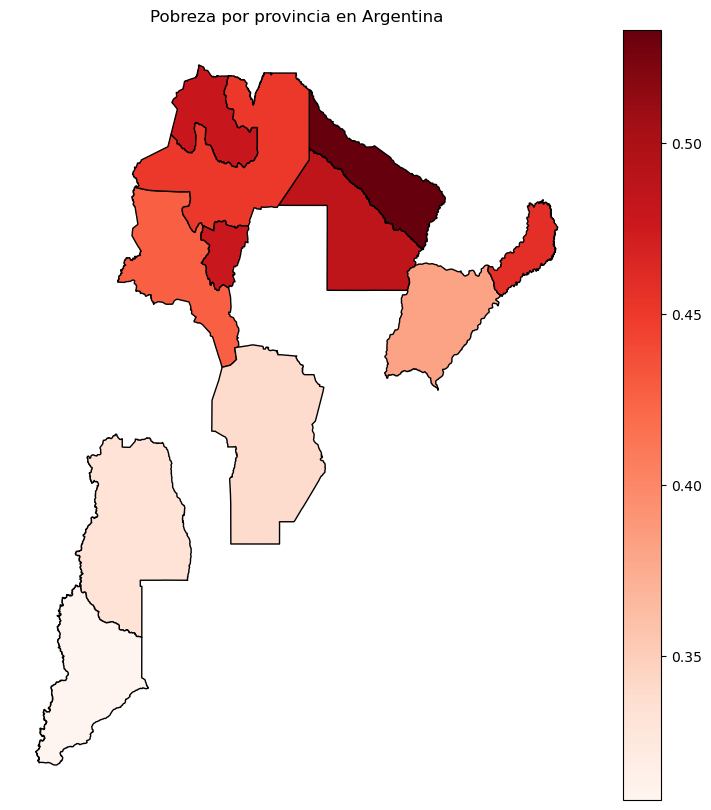

In [5]:
import matplotlib.pyplot as plt

# renombrar columnas para poder unir
pobreza = pobreza.rename(columns={
    "Provincias": "provincia",
    "Indicadores de Pobreza": "pobreza"
})

mapa = mapa.rename(columns={"NAME_1": "provincia"})

# unir datos
mapa_pobreza = mapa.merge(pobreza, on="provincia", how="left")

# graficar
fig, ax = plt.subplots(figsize=(10,10))

mapa_pobreza.plot(
    column="pobreza",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Pobreza por provincia en Argentina")
ax.axis("off")

plt.show()

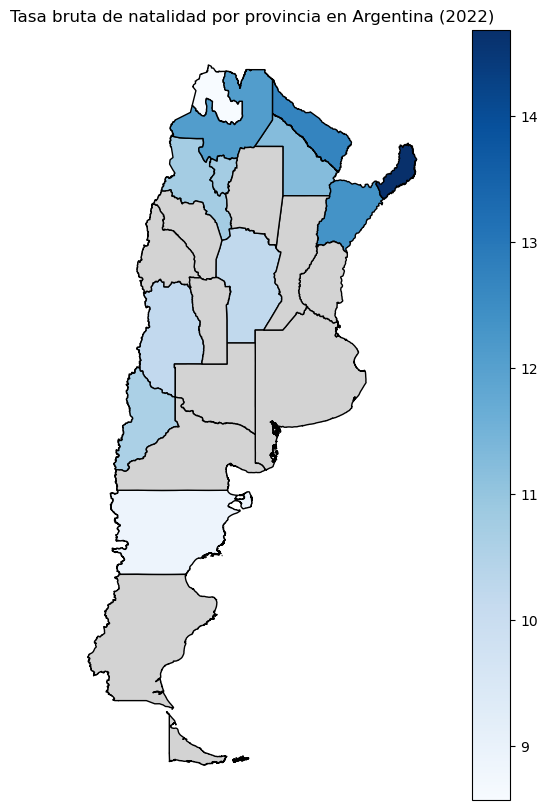

In [6]:
import matplotlib.pyplot as plt

# elegir año
nac_2022 = nacimientos[nacimientos["anio"] == 2022].copy()

# agrupar por provincia
# para tbn conviene promedio ponderado por población
nac_prov = (
    nac_2022.groupby("provincia_nombre")
    .apply(lambda x: (x["tbn"] * x["poblacion_total"]).sum() / x["poblacion_total"].sum())
    .reset_index(name="tbn")
)

# renombrar para unir con el mapa
nac_prov = nac_prov.rename(columns={"provincia_nombre": "provincia"})

# asegurarnos de que el mapa tenga la columna provincia
mapa = mapa.rename(columns={"NAME_1": "provincia"})

# corregir nombres si hace falta
mapa["provincia"] = mapa["provincia"].replace({
    "Buenos Aires City": "Ciudad Autónoma de Buenos Aires",
    "Tierra del Fuego": "Tierra del Fuego, Antártida e Islas del Atlántico Sur"
})

# unir mapa + nacimientos
mapa_nac = mapa.merge(nac_prov, on="provincia", how="left")

# graficar
fig, ax = plt.subplots(figsize=(10, 10))

mapa_nac.plot(
    column="tbn",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Sin datos"}
)

ax.set_title("Tasa bruta de natalidad por provincia en Argentina (2022)")
ax.axis("off")

plt.show()

In [8]:
datos = pobreza.merge(nac_prov, on="provincia", how="inner")

datos

,provincia,pobreza,tbn
0,Buenos Aires,0.418,9.178623
1,Catamarca,0.427,10.768533
2,Chaco,0.486,11.228122
3,Ciudad Autónoma de Buenos Aires,0.257,7.590000
4,Corrientes,0.381,12.363454
5,Córdoba,0.339,10.202142
6,Entre Ríos,0.377,10.147455
7,Formosa,0.533,12.713151
8,Jujuy,0.479,8.573961
9,La Pampa,0.329,9.206892


In [9]:
datos[["pobreza", "tbn"]].corr()

,pobreza,tbn
pobreza,1.000000,0.495749
tbn,0.495749,1.000000


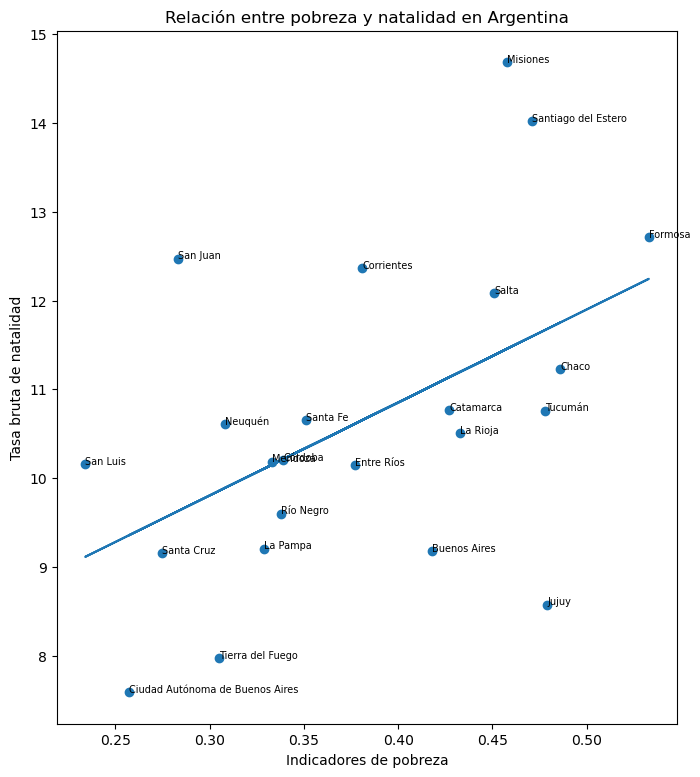

In [15]:
import matplotlib.pyplot as plt
import numpy as np

x = datos["pobreza"]
y = datos["tbn"]

# regresión lineal
coef = np.polyfit(x, y, 1)
regresion = np.poly1d(coef)

# scatter
plt.figure(figsize=(8,9))
plt.scatter(x, y)

# línea de regresión
plt.plot(x, regresion(x))

# etiquetas
for i, txt in enumerate(datos["provincia"]):
    plt.annotate(txt, (x.iloc[i], y.iloc[i]), fontsize=7)

plt.xlabel("Indicadores de pobreza")
plt.ylabel("Tasa bruta de natalidad")
plt.title("Relación entre pobreza y natalidad en Argentina")

plt.show()

In [22]:
datos[["pobreza", "tbn"]].corr()

,pobreza,tbn
pobreza,1.000000,0.495749
tbn,0.495749,1.000000


In [21]:
datos[["pobreza", "tbn"]].corr()

coef = np.polyfit(x, y, 1)
print("Pendiente:", coef[0])
print("Intercepto:", coef[1])


Pendiente: 10.470452553605833
Intercepto: 6.664197540781468


In [19]:
datos.describe()

,pobreza,tbn
count,23.000000,23.000000
mean,0.380174,10.644790
std,0.084399,1.782554
min,0.234000,7.590000
25%,0.318500,9.404309
50%,0.377000,10.505018
75%,0.454500,11.655893
max,0.533000,14.683788


In [26]:
datos.var(numeric_only=True)

pobreza    0.007123
tbn        3.177498
pred       0.780924
residuo    2.396574
dtype: float64

In [28]:
pred=      0.780924
residuo=    2.396574

datos["pred"] = regresion(x)
datos["residuo"] = y - datos["pred"]

In [30]:
datos["pred"] = regresion(x)
datos["residuo"] = y - datos["pred"]
datos.sort_values("residuo", key=abs, ascending=False)

,provincia,pobreza,tbn,pred,residuo
12,Misiones,0.458,14.683788,11.459665,3.224123
8,Jujuy,0.479,8.573961,11.679544,-3.105584
16,San Juan,0.283,12.470264,9.627336,2.842928
20,Santiago del Estero,0.471,14.018899,11.595781,2.423118
21,Tierra del Fuego,0.305,7.970941,9.857686,-1.886745
0,Buenos Aires,0.418,9.178623,11.040847,-1.862223
3,Ciudad Autónoma de Buenos Aires,0.257,7.590000,9.355104,-1.765104
4,Corrientes,0.381,12.363454,10.653440,1.710014
17,San Luis,0.234,10.155246,9.114283,1.040962
22,Tucumán,0.478,10.761505,11.669074,-0.907569


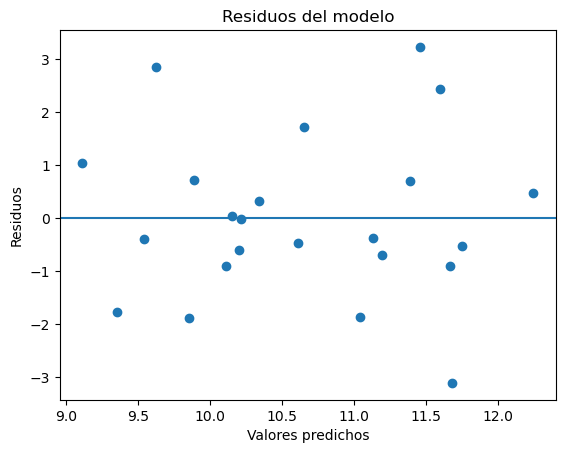

In [31]:
plt.scatter(datos["pred"], datos["residuo"])
plt.axhline(0)
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos del modelo")
plt.show()